# Análisis bidimensional de close

Notebook reproducible, limitado a DEVELOPMENT.

In [1]:
"""EDA bidimensional: close y derivados; volatilidad centrada ddof=0; solo DEVELOPMENT."""
from pathlib import Path
import hashlib
import itertools
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import sklearn
from sklearn.feature_selection import mutual_info_regression

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/splits/development_80.csv').is_file())
SYMBOLS = ['BTCUSDT','ETHUSDT','BNBUSDT','XRPUSDT','SOLUSDT']
FEATURES = ['close','close_lag_1h','close_lag_24h','return_1h_pct','abs_return_1h_pct','sigma_past_24h_pct']
TARGET = 'sigma_future_24h_pct'


def block_means(values, length, reps=1999, seed=42):
    """Bootstrap circular pareado sobre calendario completo, sin comprimir huecos."""
    n = len(values)
    good = np.isfinite(values).all(axis=1)
    filled = np.where(good[:,None], values, 0.)
    extended = np.concatenate([filled, filled[:length]], axis=0)
    mask = np.concatenate([good.astype(int), good[:length].astype(int)])
    cs = np.vstack([np.zeros((1,values.shape[1])), extended.cumsum(axis=0)])
    cc = np.r_[0,mask.cumsum()]
    sums = cs[length:length+n]-cs[:n]
    counts = cc[length:length+n]-cc[:n]
    rng = np.random.default_rng(seed)
    full, remainder = divmod(n,length)
    starts = rng.integers(n,size=(reps,full))
    total = sums[starts].sum(axis=1); denominator = counts[starts].sum(axis=1)
    if remainder:
        tail = rng.integers(n,size=reps)
        total += cs[tail+remainder]-cs[tail]
        denominator += cc[tail+remainder]-cc[tail]
    assert (denominator>0).all()
    return total/denominator[:,None]


def main():
    source=ROOT/'data/splits/development_80.csv'
    fingerprint=hashlib.sha256(source.read_bytes()).hexdigest()
    df=pd.read_csv(source,usecols=['symbol','open_time','close_time','close'])
    for field in ['open_time','close_time']: df[field]=pd.to_datetime(df[field],format='ISO8601',utc=True)
    start=pd.Timestamp('2020-08-11 06:00',tz='UTC');end=pd.Timestamp('2025-07-01 18:00',tz='UTC')
    assert len(df)==214165 and set(df.symbol)==set(SYMBOLS) and df.open_time.between(start,end).all()
    assert not df.duplicated(['symbol','open_time']).any()
    assert np.isfinite(df.close).all() and df.close.gt(0).all()
    grid=pd.date_range(start,end,freq='h',name='anchor_open_time')
    tables=ROOT/'outputs/tables';figures=ROOT/'book/_static/figures'
    tables.mkdir(parents=True,exist_ok=True);figures.mkdir(parents=True,exist_ok=True)
    groups={}; associations=[];vifs=[];coverage=[]; matrices=[]
    for symbol in SYMBOLS:
        g=df.loc[df.symbol.eq(symbol)].set_index('open_time').reindex(grid)
        valid=g.close.notna() & g.close_time.eq(grid+pd.Timedelta(hours=1)-pd.Timedelta(milliseconds=1))
        c=g.close.where(valid);r=np.log(c).diff()
        x=pd.DataFrame({'close':c,'close_lag_1h':c.shift(1),'close_lag_24h':c.shift(24),
                        'return_1h_pct':100*r,'abs_return_1h_pct':100*r.abs(),
                        'sigma_past_24h_pct':100*r.rolling(24,min_periods=24).std(ddof=0),
                        TARGET:100*r.rolling(24,min_periods=24).std(ddof=0).shift(-24)},index=grid)
        forward=valid.astype(int).rolling(25).sum().shift(-24).eq(25)
        x[TARGET]=x[TARGET].where(forward)
        # Comprobación independiente de cada objetivo contra los 24 retornos futuros.
        windows=np.lib.stride_tricks.sliding_window_view(c.to_numpy(),25)
        direct=100*np.std(np.diff(np.log(windows),axis=1),axis=1,ddof=0)
        good=x[TARGET].iloc[:-24].notna().to_numpy()
        assert np.allclose(x[TARGET].iloc[:-24].to_numpy()[good],direct[good],rtol=1e-9,atol=1e-10)
        assert x[TARGET].iloc[-24:].isna().all()
        common=x.dropna();groups[symbol]=x
        coverage.append(dict(symbol=symbol,observed=int(g.close.notna().sum()),valid_target=int(x[TARGET].notna().sum()),complete_pairs=len(common)))
        # Escala auxiliar para estimación MI/VIF, sin crear un preprocesador de modelado.
        z=(common[FEATURES]-common[FEATURES].mean())/common[FEATURES].std(ddof=0)
        mi=mutual_info_regression(z,common[TARGET],n_neighbors=5,random_state=42)
        for j,field in enumerate(FEATURES):
            associations.append(dict(symbol=symbol,predictor=field,n=len(common),
                pearson=common[field].corr(common[TARGET]),spearman=common[field].corr(common[TARGET],method='spearman'),mi_nats=mi[j]))
            others=np.column_stack([np.ones(len(z)),z.drop(columns=field)])
            residual=z[field].to_numpy()-others@np.linalg.lstsq(others,z[field],rcond=None)[0]
            ratio=np.dot(residual,residual)/np.dot(z[field],z[field])
            vifs.append(dict(symbol=symbol,predictor=field,n=len(common),vif=1/ratio if ratio>1e-14 else np.inf))
        for method in ['pearson','spearman']:
            corr=common.corr(method=method)
            for a in corr:
                for b in corr: matrices.append(dict(symbol=symbol,method=method,row=a,column=b,value=corr.loc[a,b]))
        fig,axes=plt.subplots(2,3,figsize=(14,8),constrained_layout=True)
        for ax,field in zip(axes.flat,FEATURES):
            im=ax.hexbin(common[field],common[TARGET],gridsize=40,bins='log',mincnt=1,cmap='Blues')
            ax.set_xlabel(field);ax.set_ylabel('Volatilidad futura (%)');fig.colorbar(im,ax=ax,label='Pares (log)')
        fig.suptitle(f'{symbol} · close y derivados frente al objetivo · DEVELOPMENT')
        fig.savefig(figures/f'bivariate_{symbol}.png',dpi=130);plt.close(fig)
    assoc=pd.DataFrame(associations);vif=pd.DataFrame(vifs)
    assoc.to_csv(tables/'bivariate_associations.csv',index=False)
    vif.to_csv(tables/'bivariate_vif.csv',index=False)
    pd.DataFrame(coverage).to_csv(tables/'bivariate_coverage.csv',index=False)
    pd.DataFrame(matrices).to_csv(tables/'bivariate_correlations.csv',index=False)
    aligned=pd.DataFrame({s:groups[s][TARGET] for s in SYMBOLS})
    common=aligned.dropna(); common.to_csv(tables/'bivariate_target_aligned.csv')
    descriptions=common.describe(percentiles=[.25,.5,.75]).T
    descriptions.to_csv(tables/'bivariate_group_summary.csv')
    comparisons=[]
    for length in [24,168,336]:
        means=block_means(aligned.to_numpy(),length)
        rows=[]
        for i,j in itertools.combinations(range(5),2):
            d=common.iloc[:,i]-common.iloc[:,j];estimate=d.mean()
            boot=means[:,i]-means[:,j]
            p=(1+np.count_nonzero(np.abs(boot-estimate)>=abs(estimate)))/(len(boot)+1)
            rows.append(dict(block_hours=length,asset_a=SYMBOLS[i],asset_b=SYMBOLS[j],n=len(d),
                difference_pp=estimate,paired_effect=estimate/d.std(ddof=1),ci_low=np.quantile(boot,.025),
                ci_high=np.quantile(boot,.975),p_raw=p))
        # Holm en la familia de diez comparaciones de cada longitud de bloque.
        order=np.argsort([a['p_raw'] for a in rows]);adjusted=np.maximum.accumulate([(10-k)*rows[idx]['p_raw'] for k,idx in enumerate(order)])
        for idx,p in zip(order,adjusted):rows[idx]['p_holm']=min(1.,p)
        comparisons.extend(rows)
    pd.DataFrame(comparisons).to_csv(tables/'bivariate_group_comparisons.csv',index=False)
    fig,ax=plt.subplots(figsize=(10,5),constrained_layout=True)
    ax.boxplot([common[s] for s in SYMBOLS],tick_labels=SYMBOLS,flierprops={'marker':'.','markersize':2,'alpha':.2})
    ax.set_ylabel('Volatilidad futura 24h (%) · desviación ddof=0')
    ax.set_title(f'Activo y volatilidad · {len(common):,} timestamps comunes');ax.grid(alpha=.2)
    fig.savefig(figures/'bivariate_groups.png',dpi=150);plt.close(fig)
    for method in ['pearson','spearman']:
        fig,axes=plt.subplots(2,3,figsize=(17,11),constrained_layout=True)
        for ax,symbol in zip(axes.flat,SYMBOLS):
            corr=groups[symbol].dropna().corr(method=method)
            im=ax.imshow(corr,vmin=-1,vmax=1,cmap='RdBu_r')
            labels=['close','lag 1h','lag 24h','retorno','|retorno|','sigma pasada','sigma futura']
            ax.set_xticks(range(7),labels,rotation=65,ha='right');ax.set_yticks(range(7),labels);ax.set_title(symbol)
            for i in range(7):
                for j in range(7):ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=7,color='white' if abs(corr.iloc[i,j])>.6 else 'black')
        axes.flat[-1].axis('off');fig.colorbar(im,ax=list(axes.flat),shrink=.6)
        fig.suptitle(f'Correlaciones {method} · muestra completa por activo')
        fig.savefig(figures/f'bivariate_heatmap_{method}.png',dpi=140);plt.close(fig)
    assert fingerprint==hashlib.sha256(source.read_bytes()).hexdigest()
    (tables/'bivariate_metadata.json').write_text(json.dumps({'source':'data/splits/development_80.csv','sha256':fingerprint,
        'target':'100 * std(r[t+1],...,r[t+24], ddof=0); t etiqueta la apertura de la última vela cerrada',
        'forecast_time':'t + 1 hora; datos disponibles después del cierre',
        'bootstrap':{'reps':1999,'seed':42,'main_block_hours':168,'sensitivity':[24,336],
                     'method':'Circular pareado sobre calendario; medias solo sobre filas comunes válidas'},
        'MI':{'neighbors':5,'seed':42,'units':'nats'},'target_ddof':0,'test_read':False,
        'versions':{'pandas':pd.__version__,'numpy':np.__version__,'sklearn':sklearn.__version__,'matplotlib':matplotlib.__version__}},ensure_ascii=False,indent=2),encoding='utf-8')
    print(pd.DataFrame(coverage).to_string(index=False))
    print(assoc.to_string(index=False));print(vif.to_string(index=False))
    print(pd.DataFrame(comparisons).query('block_hours == 168').to_string(index=False))
    return assoc


if __name__=='__main__':main()


 symbol  observed  valid_target  complete_pairs
BTCUSDT     42833         42539           42251
ETHUSDT     42833         42539           42251
BNBUSDT     42833         42539           42251
XRPUSDT     42833         42564           42300
SOLUSDT     42833         42564           42300
 symbol          predictor     n   pearson  spearman  mi_nats
BTCUSDT              close 42251 -0.033923  0.060176 0.634727
BTCUSDT       close_lag_1h 42251 -0.033553  0.060285 0.595453
BTCUSDT      close_lag_24h 42251 -0.027470  0.062980 0.549503
BTCUSDT      return_1h_pct 42251 -0.028821 -0.001364 0.084692
BTCUSDT  abs_return_1h_pct 42251  0.358978  0.344128 0.076684
BTCUSDT sigma_past_24h_pct 42251  0.596390  0.581812 0.434710
ETHUSDT              close 42251 -0.007358  0.035650 0.497366
ETHUSDT       close_lag_1h 42251 -0.006425  0.036008 0.460407
ETHUSDT      close_lag_24h 42251  0.006969  0.042591 0.436158
ETHUSDT      return_1h_pct 42251 -0.041853 -0.003952 0.087436
ETHUSDT  abs_return_1h_pct 422

## 2.3 Análisis bidimensional

El análisis se centra en `close` y en variables construidas exclusivamente a partir de sus precios históricos. No se incorporan volúmenes ni otros campos de mercado como predictores. `symbol` identifica las entidades y las fechas permiten alinear las observaciones. Todos los cálculos utilizan DEVELOPMENT; TEST permanece reservado.

### 2.3.1 Variables, objetivo y alineación temporal

El objetivo de esta sección se calcula con la desviación estándar de los 24 retornos futuros, centrados en su media y con divisor 24 (`ddof=0`). Se presenta en porcentaje, sin anualizar. Estos resultados son nuevos y no reutilizan las cifras de la definición anterior de 2.1.

Para precisar los índices, sea $s$ la hora de apertura de la última vela observada y $C_{i,s}$ su cierre. La predicción se sitúa después del cierre de esa vela, alrededor de $s+1$ hora. Con $r_{i,s}=\ln(C_{i,s}/C_{i,s-1})$:

$$
\bar r^+_{i,s}=\frac{1}{24}\sum_{j=1}^{24}r_{i,s+j},\qquad
y_{i,s}=100\sqrt{\frac{1}{24}\sum_{j=1}^{24}(r_{i,s+j}-\bar r^+_{i,s})^2}.
$$

Esta notación etiqueta las filas mediante la última vela observada; corresponde a la definición común con instante de referencia $t=s+1$. El factor 100 convierte la desviación en porcentaje, sin cambiar su significado financiero.

| Variable | Construcción y disponibilidad |
|----------|-------------------------------|
| `close` | Cierre de la última vela observada. |
| `close_lag_1h` | Cierre una hora antes, con desplazamiento por calendario. |
| `close_lag_24h` | Cierre 24 horas antes, con desplazamiento por calendario. |
| `return_1h_pct` | $100r_{i,s}$, retorno de la última hora observada. |
| `abs_return_1h_pct` | $100\lvert r_{i,s}\rvert$, magnitud del movimiento reciente. |
| `sigma_past_24h_pct` | Desviación estándar de los retornos $r_{i,s-23},\ldots,r_{i,s}$, con divisor 24 y multiplicada por 100. |
| `sigma_future_24h_pct` | Objetivo $y_{i,s}$, conocido únicamente al finalizar el horizonte futuro. |

Los rezagos de una y 24 horas son candidatos exploratorios, no una selección definitiva de la ventana de entrada de los modelos. Las ventanas de volatilidad requieren 25 cierres consecutivos y convencionales; los huecos, cierres irregulares y horizontes que sobrepasan DEVELOPMENT no se imputan. Los retornos pasados y futuros no se solapan, aunque comparten el cierre de frontera.

Para comparar asociaciones y VIF dentro de cada activo se usa la misma muestra de filas completas en las seis variables candidatas y el objetivo. Esto evita que los coeficientes difieran solo por utilizar conjuntos distintos de observaciones.

| Activo | Velas observadas | Objetivos válidos | Filas completas |
| --- | ---: | ---: | ---: |
| BTCUSDT | 42,833 | 42,539 | 42,251 |
| ETHUSDT | 42,833 | 42,539 | 42,251 |
| BNBUSDT | 42,833 | 42,539 | 42,251 |
| XRPUSDT | 42,833 | 42,564 | 42,300 |
| SOLUSDT | 42,833 | 42,564 | 42,300 |

### 2.3.2 Numéricas frente a numéricas: gráficos y correlaciones

Se calculan Pearson y Spearman por activo. Pearson describe asociación lineal; Spearman describe asociación monótona mediante rangos. Los coeficientes se interpretan como tamaños de asociación descriptivos y no se acompañan de valores p basados en independencia de filas horarias.

Los gráficos hexbin incluyen todos los pares de la muestra completa. El color representa su frecuencia en escala logarítmica y permite visualizar concentraciones y observaciones dispersas sin ocultarlas mediante un muestreo de puntos.


#### BTCUSDT

| Candidato | Pearson | Spearman | MI (nats) |
| --- | ---: | ---: | ---: |
| close | -0.034 | 0.060 | 0.635 |
| close_lag_1h | -0.034 | 0.060 | 0.595 |
| close_lag_24h | -0.027 | 0.063 | 0.550 |
| return_1h_pct | -0.029 | -0.001 | 0.085 |
| abs_return_1h_pct | 0.359 | 0.344 | 0.077 |
| sigma_past_24h_pct | 0.596 | 0.582 | 0.435 |



#### ETHUSDT

| Candidato | Pearson | Spearman | MI (nats) |
| --- | ---: | ---: | ---: |
| close | -0.007 | 0.036 | 0.497 |
| close_lag_1h | -0.006 | 0.036 | 0.460 |
| close_lag_24h | 0.007 | 0.043 | 0.436 |
| return_1h_pct | -0.042 | -0.004 | 0.087 |
| abs_return_1h_pct | 0.386 | 0.357 | 0.088 |
| sigma_past_24h_pct | 0.649 | 0.623 | 0.476 |



#### BNBUSDT

| Candidato | Pearson | Spearman | MI (nats) |
| --- | ---: | ---: | ---: |
| close | -0.124 | -0.071 | 0.506 |
| close_lag_1h | -0.123 | -0.070 | 0.468 |
| close_lag_24h | -0.117 | -0.067 | 0.436 |
| return_1h_pct | -0.013 | 0.007 | 0.125 |
| abs_return_1h_pct | 0.463 | 0.406 | 0.137 |
| sigma_past_24h_pct | 0.709 | 0.697 | 0.544 |



#### XRPUSDT

| Candidato | Pearson | Spearman | MI (nats) |
| --- | ---: | ---: | ---: |
| close | 0.125 | 0.213 | 0.495 |
| close_lag_1h | 0.125 | 0.213 | 0.464 |
| close_lag_24h | 0.123 | 0.208 | 0.445 |
| return_1h_pct | 0.002 | 0.010 | 0.103 |
| abs_return_1h_pct | 0.413 | 0.370 | 0.106 |
| sigma_past_24h_pct | 0.625 | 0.638 | 0.472 |



#### SOLUSDT

| Candidato | Pearson | Spearman | MI (nats) |
| --- | ---: | ---: | ---: |
| close | -0.206 | -0.184 | 0.484 |
| close_lag_1h | -0.206 | -0.184 | 0.457 |
| close_lag_24h | -0.204 | -0.184 | 0.434 |
| return_1h_pct | -0.007 | 0.000 | 0.093 |
| abs_return_1h_pct | 0.416 | 0.349 | 0.099 |
| sigma_past_24h_pct | 0.687 | 0.668 | 0.466 |




La volatilidad pasada presenta correlaciones de Pearson entre 0.596 y 0.709 y de Spearman entre 0.582 y 0.697 con la volatilidad futura. El retorno con signo muestra asociación lineal pequeña, mientras que su magnitud absoluta alcanza Pearson entre 0.359 y 0.463. Esto sugiere que la intensidad del movimiento reciente describe mejor la variabilidad futura que su dirección, sin demostrar desempeño predictivo fuera de muestra.

El precio de cierre tiene asociaciones de Pearson débiles en valor absoluto, con signos diferentes entre activos. Las figuras muestran dispersión, cambios de escala y relaciones que no quedan resumidas por una recta. Los patrones de `close` y sus rezagos son muy parecidos, lo que debe contrastarse con la revisión de multicolinealidad.

### 2.3.3 Predictoras frente al objetivo: información mutua

Las tablas anteriores incluyen información mutua (MI), estimada mediante vecinos próximos con `n_neighbors=5` y semilla 42, expresada en nats. Se utiliza [mutual_info_regression de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_regression.html). Para estabilidad numérica, los predictores se estandarizan dentro de la muestra descriptiva de cada activo; ese escalado no se guarda ni se utiliza para entrenar modelos.

La MI puede detectar dependencia que Pearson no resume, pero no indica el signo de una relación, no es una correlación entre cero y uno y no es un valor p. En estas estimaciones, `close` presenta MI entre 0.484 y 0.635 nats, pese a sus asociaciones lineales débiles; la volatilidad pasada presenta entre 0.435 y 0.544 nats.

No se interpreta la MI alta del nivel de precio como prueba de una relación no lineal estable: la dependencia temporal, las ventanas de objetivo solapadas y la mezcla de periodos de mercado pueden producir asociaciones elevadas en toda la muestra. Tampoco se ordenan definitivamente las variables por esta cifra. Su utilidad deberá comprobarse en bloques cronológicos no usados para ajustar cada modelo.

### 2.3.4 Categórica frente a numérica: activo y volatilidad

Se compara `symbol` con la volatilidad futura calculada a partir de `close`. La comparación se realiza sobre 42,539 timestamps con objetivo válido simultáneamente en los cinco activos. Se evita comparar niveles nominales de precio como si un activo más caro tuviera necesariamente mayor riesgo.

| Activo | Media (%) | Mediana (%) | Q1 (%) | Q3 (%) |
| --- | ---: | ---: | ---: | ---: |
| BTCUSDT | 0.5507 | 0.4854 | 0.3335 | 0.6738 |
| ETHUSDT | 0.7129 | 0.6196 | 0.4355 | 0.8769 |
| BNBUSDT | 0.6875 | 0.5589 | 0.3731 | 0.8298 |
| XRPUSDT | 0.8756 | 0.6764 | 0.4628 | 1.0177 |
| SOLUSDT | 1.1414 | 0.9607 | 0.6814 | 1.3717 |



Las observaciones de distintos activos están emparejadas por fecha y pueden compartir movimientos. Además, cada serie presenta dependencia temporal y las etiquetas consecutivas comparten retornos. Por ello no se aplican pruebas t, ANOVA, Mann–Whitney o Kruskal–Wallis como si se tratara de grupos de observaciones independientes. Se emplea una alternativa de remuestreo temporal pareado para comparar medias.

### 2.3.5 Comparación entre grupos y rigor estadístico

Se utiliza bootstrap circular por bloques: 1,999 réplicas, semilla 42 y longitud principal de 168 horas, fijada antes de examinar los resultados para conservar segmentos de una semana y superar el solapamiento de 24 horas del objetivo. Se remuestrea la misma secuencia de bloques para los cinco activos, conservando los huecos sobre la cuadrícula horaria y calculando las medias únicamente sobre observaciones comunes válidas. El último bloque se recorta para mantener la longitud original del calendario. La [documentación de bootstrap temporal de arch](https://arch.readthedocs.io/en/stable/bootstrap/timeseries-bootstraps.html) describe el remuestreo circular mediante bloques de longitud fija.

Para cada par se informa la diferencia media $\bar d=\operatorname{media}(y_A-y_B)$ en puntos porcentuales, el efecto estandarizado pareado $d_z=\bar d/s_d$, un intervalo percentil del 95% y un valor p bilateral aproximado obtenido de las diferencias bootstrap centradas. El valor p se calcula como $(1+\#\{|\bar d^*-\bar d|\geq|\bar d|\})/(B+1)$, con $B=1999$. La hipótesis contrastada es diferencia media nula; no igualdad de todas las características de las distribuciones.

Se aplica Holm a la familia de diez comparaciones por pares. Los intervalos mostrados son individuales, no simultáneos; la corrección múltiple se aplica a los valores p. La resolución mínima del valor p sin ajustar es 0.0005: no se reportan probabilidades exactamente cero.

| Par A−B | Diferencia (pp) | Efecto pareado | IC 95% individual | p sin ajustar | p Holm |
| --- | ---: | ---: | ---: | ---: | ---: |
| BTCUSDT − ETHUSDT | -0.1622 | -0.7557 | [-0.1809; -0.1448] | 0.0005 | 0.0050 |
| BTCUSDT − BNBUSDT | -0.1368 | -0.3689 | [-0.1747; -0.1031] | 0.0005 | 0.0050 |
| BTCUSDT − XRPUSDT | -0.3249 | -0.5688 | [-0.3752; -0.2789] | 0.0005 | 0.0050 |
| BTCUSDT − SOLUSDT | -0.5907 | -1.0671 | [-0.6423; -0.5410] | 0.0005 | 0.0050 |
| ETHUSDT − BNBUSDT | 0.0254 | 0.0715 | [-0.0100; 0.0589] | 0.1385 | 0.1385 |
| ETHUSDT − XRPUSDT | -0.1627 | -0.2915 | [-0.2120; -0.1167] | 0.0005 | 0.0050 |
| ETHUSDT − SOLUSDT | -0.4285 | -0.8641 | [-0.4736; -0.3837] | 0.0005 | 0.0050 |
| BNBUSDT − XRPUSDT | -0.1881 | -0.3304 | [-0.2382; -0.1409] | 0.0005 | 0.0050 |
| BNBUSDT − SOLUSDT | -0.4539 | -0.9031 | [-0.4996; -0.4112] | 0.0005 | 0.0050 |
| XRPUSDT − SOLUSDT | -0.2658 | -0.3994 | [-0.3272; -0.2076] | 0.0005 | 0.0050 |

Con bloques de 168 horas, nueve comparaciones tienen $p_{Holm}=0.005$ y ETH–BNB no muestra evidencia suficiente de diferencia media ($p_{Holm}=0.1385$). La diferencia ETH–BNB es pequeña, 0.0254 puntos porcentuales, con efecto estandarizado 0.0715; su intervalo incluye cero. No rechazar la hipótesis no demuestra igualdad entre ambos activos.

Se examinó la sensibilidad a bloques de 24 y 336 horas. En ETH–BNB, el valor p ajustado cambia de 0.005 con 24 horas a 0.1385 con 168 y 0.2345 con 336. Esta sensibilidad impide presentar la separación entre ambos como un hallazgo estable. Las otras nueve comparaciones mantienen $p_{Holm}=0.005$ en las tres longitudes. La corrección se aplica por separado en cada escenario; los escenarios alternativos son sensibilidad y no se elige el de menor valor p. Los [resultados completos](../outputs/tables/bivariate_group_comparisons.csv) incluyen las tres longitudes.

El bootstrap no elimina todas las limitaciones: su interpretación depende de que los bloques representen adecuadamente la dependencia y de una estabilidad temporal suficiente. Los cambios de régimen y la unión circular del final con el inicio pueden afectar la inferencia. Los valores p e intervalos son aproximaciones exploratorias condicionadas al periodo, no evidencia causal ni garantía de generalización. La importancia sustantiva se evalúa con las diferencias y tamaños de efecto, no solo con la significancia.

### 2.3.6 Categóricas frente a categóricas

No aplica: solo se dispone de `symbol` como variable categórica del alcance analizado. No existe una segunda variable categórica para construir una tabla de contingencia, realizar chi-cuadrado o calcular V de Cramér. No se discretiza el objetivo ni se crean clases artificiales para cumplir este apartado, pues eso cambiaría la pregunta de regresión.

### 2.3.7 Matrices de correlación y multicolinealidad

**Alcance de la multicolinealidad.** `close` es la única variable explicativa original del proyecto. Los rezagos, los retornos y la volatilidad pasada son transformaciones de su histórico, no variables originales adicionales. Si la entrada contiene una sola columna de `close`, la multicolinealidad entre predictores no aplica. Si se construye una ventana con varios cierres históricos, cada rezago constituye una entrada distinta y puede existir multicolinealidad entre esas columnas.

Los VIF presentados a continuación corresponden exclusivamente a la matriz exploratoria que incluye simultáneamente `close`, sus rezagos de 1 y 24 horas, el retorno, su magnitud y la volatilidad pasada. La multicolinealidad detectada describe esa combinación de columnas; no es una propiedad de `close` por sí sola ni implica que todos esos derivados se utilizarán como entradas del modelo. La variable objetivo continúa siendo la volatilidad futura.





Se calcula $VIF_j=1/(1-R_j^2)$ para cada uno de los seis predictores, regresándolo sobre los otros cinco con intercepto. Son regresiones auxiliares de diagnóstico, no modelos de pronóstico entrenados o evaluados. Se estandarizan las columnas para estabilidad numérica. El objetivo se excluye del cálculo. El VIF describe [multicolinealidad de la matriz de diseño](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html), no asociación con el objetivo.

| Candidato | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | ---: | ---: | ---: | ---: | ---: |
| close | 33,075.03 | 13,899.32 | 14,756.26 | 7,249.48 | 6,174.40 |
| close_lag_1h | 33,244.55 | 13,987.80 | 14,854.04 | 7,351.22 | 6,304.62 |
| close_lag_24h | 298.40 | 102.97 | 151.75 | 123.86 | 163.86 |
| return_1h_pct | 5.16 | 6.13 | 4.55 | 2.80 | 1.86 |
| abs_return_1h_pct | 1.27 | 1.31 | 1.41 | 1.35 | 1.33 |
| sigma_past_24h_pct | 1.26 | 1.31 | 1.42 | 1.37 | 1.37 |

Los VIF de `close` y su rezago de una hora superan 6,000 en todos los activos; el rezago de 24 horas también presenta valores superiores a 100. Incluir simultáneamente los tres niveles aporta una fuerte redundancia lineal. Los VIF de la magnitud del retorno y la volatilidad pasada se sitúan aproximadamente entre 1.26 y 1.42 en esta matriz. Los VIF elevados pueden dificultar la interpretación de coeficientes; no son una regla universal de eliminación para todos los algoritmos.

### 2.3.8 Interpretación y selección preliminar

Los resultados motivan considerar la volatilidad pasada y la magnitud del retorno como candidatos derivados de `close`, y revisar la conveniencia de introducir simultáneamente varios niveles de precio muy correlacionados. El retorno con signo conserva una asociación lineal pequeña, pero ello no descarta relaciones condicionales o no lineales. No se eliminan variables ni se fija la matriz final de entrada en esta etapa.

La selección preliminar es una hipótesis de trabajo: cualquier comparación de conjuntos de variables, regularización o transformación se realizará dentro de la validación cronológica de DEVELOPMENT. Los modelos deberán compartir la información disponible y las observaciones de evaluación según el protocolo común. No se utilizan los resultados de esta exploración para afirmar qué algoritmo será mejor.

### 2.3.9 Reproducibilidad

El procedimiento está en `src/11_bivariate_close.py`. Las tablas y trazabilidad se guardan en `outputs/tables/bivariate_*.csv` y `outputs/tables/bivariate_metadata.json`; las figuras se guardan en `book/_static/figures/bivariate_*.png`. Cada objetivo válido se verifica contra el cálculo directo de la desviación estándar de sus 24 retornos futuros. Se comprueban la alineación temporal y la conservación de DEVELOPMENT mediante SHA-256. Los datos originales y TEST permanecen intactos.


bivariate_BNBUSDT.png


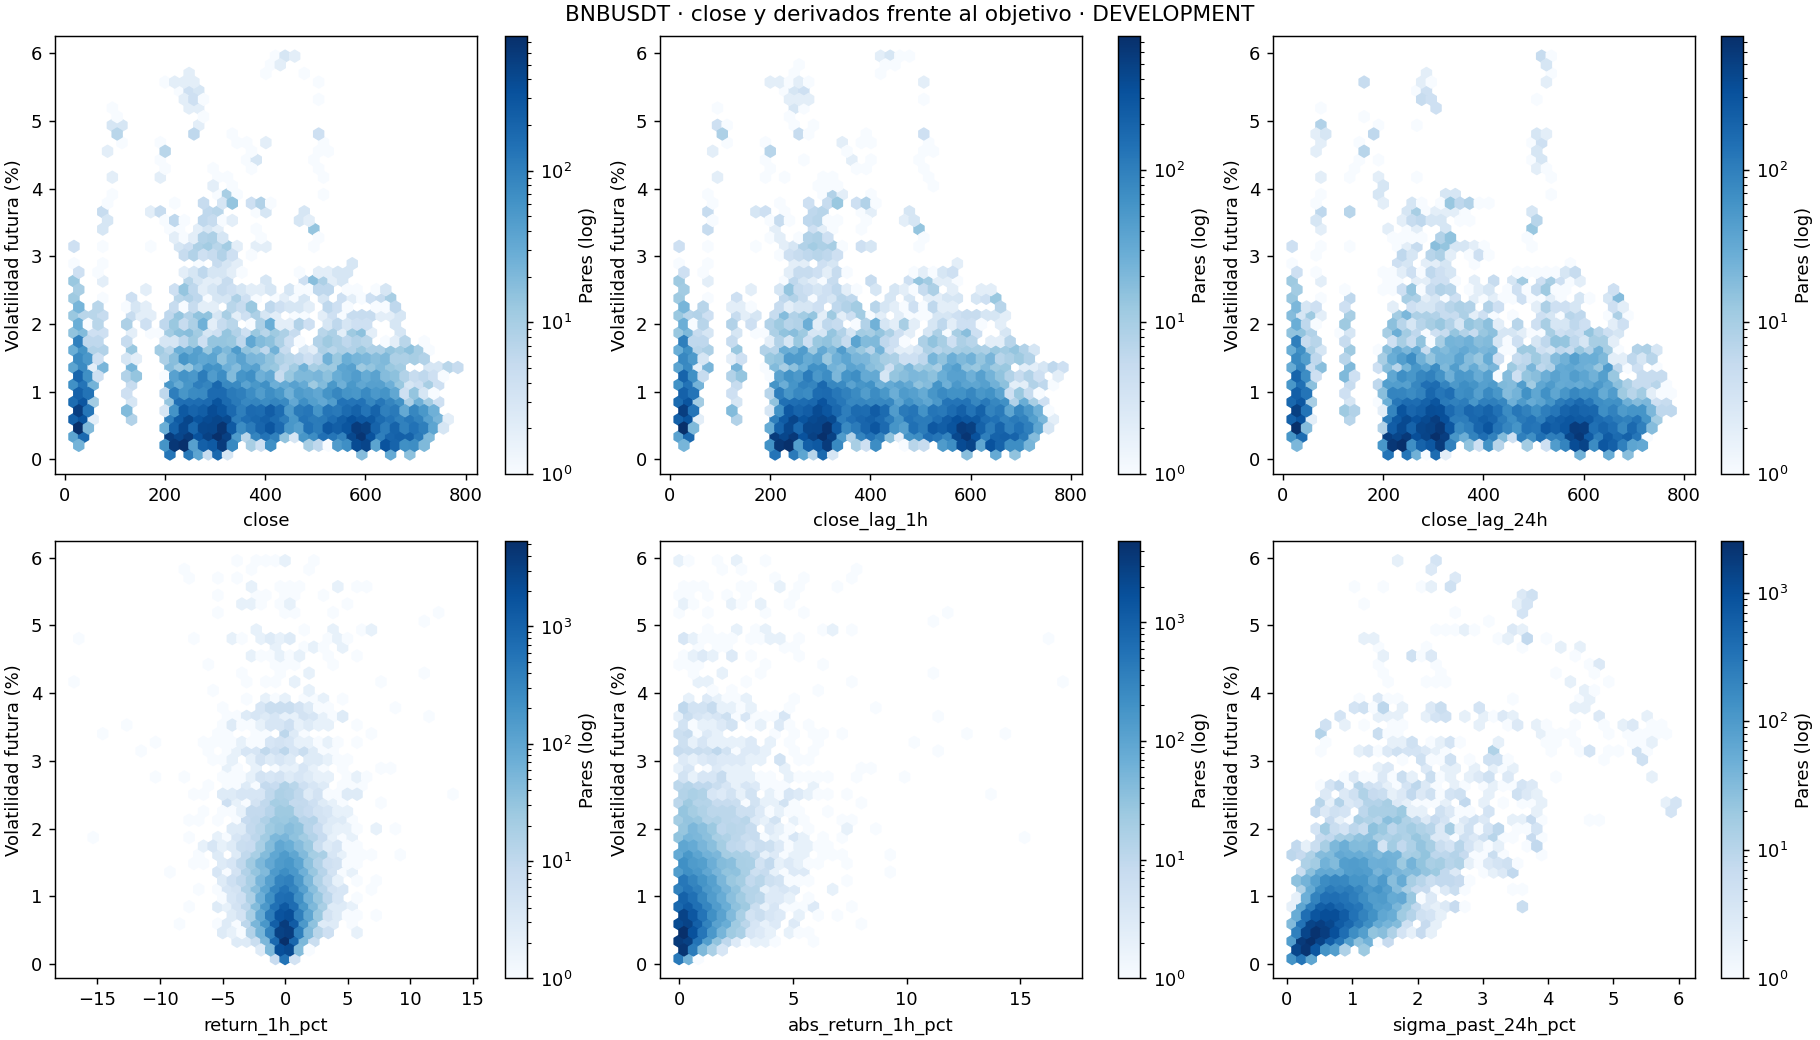

bivariate_BTCUSDT.png


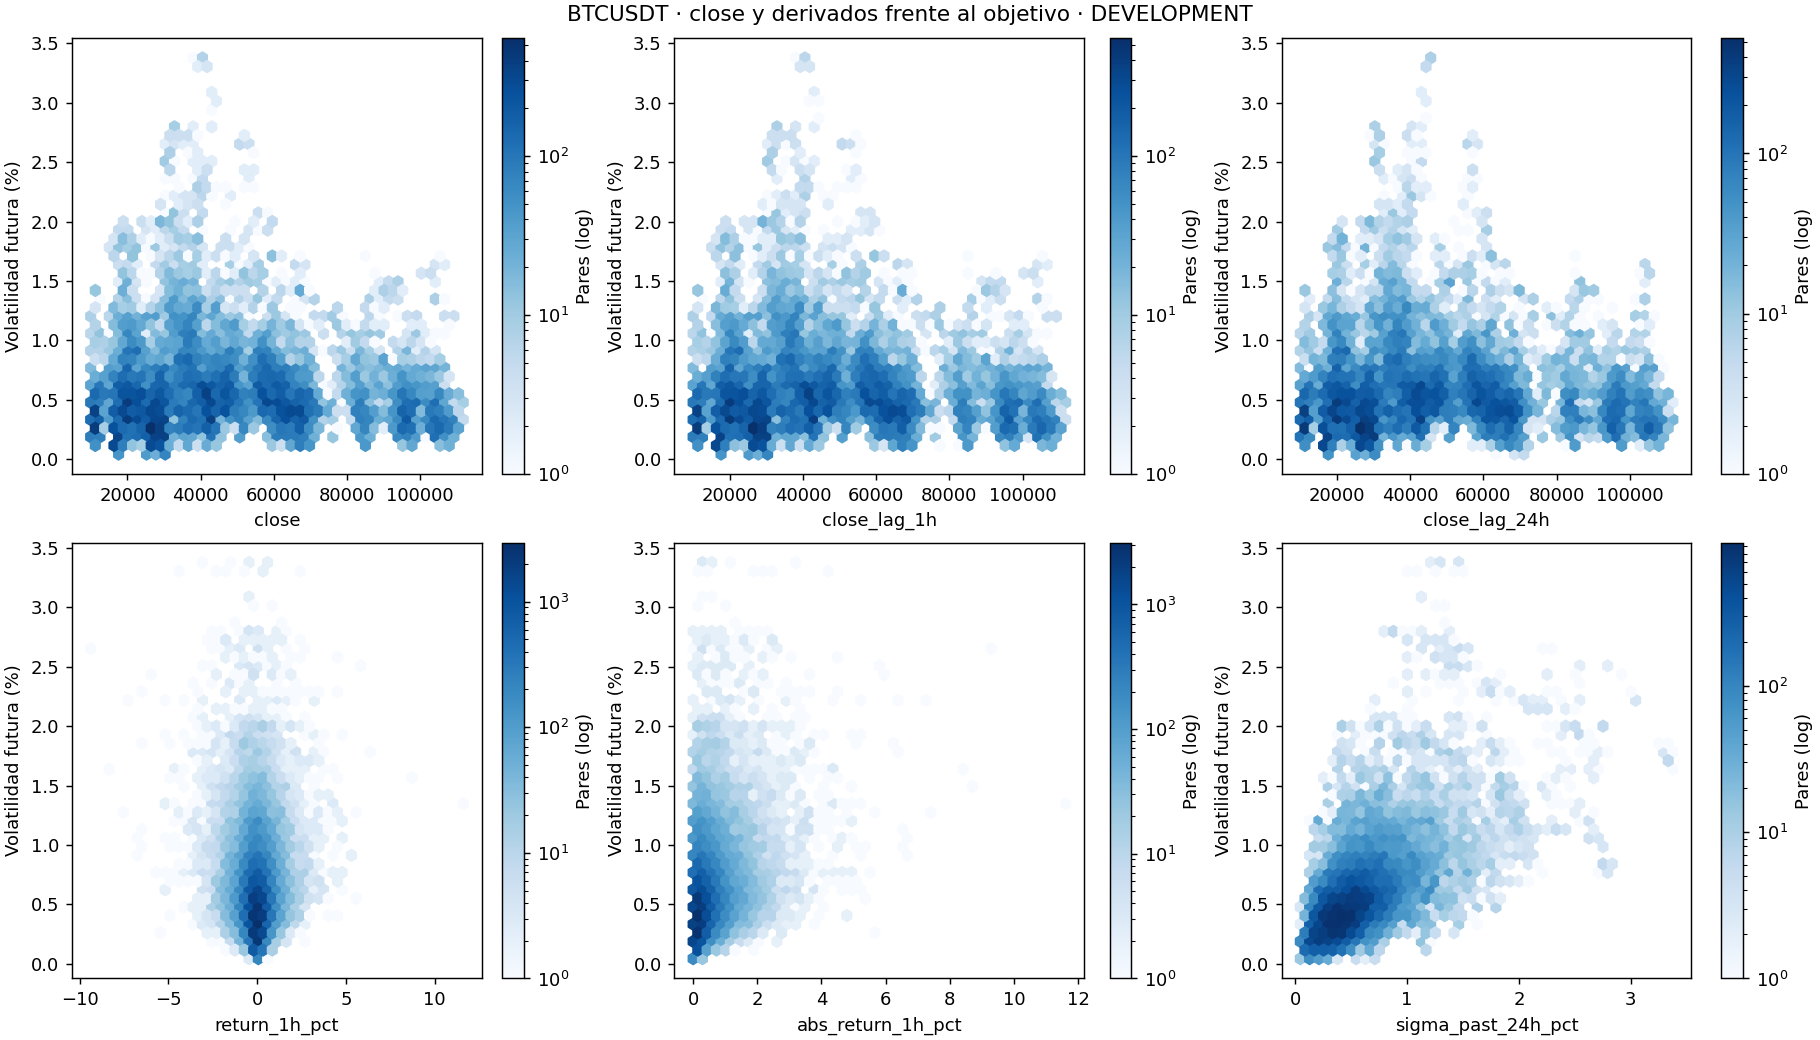

bivariate_ETHUSDT.png


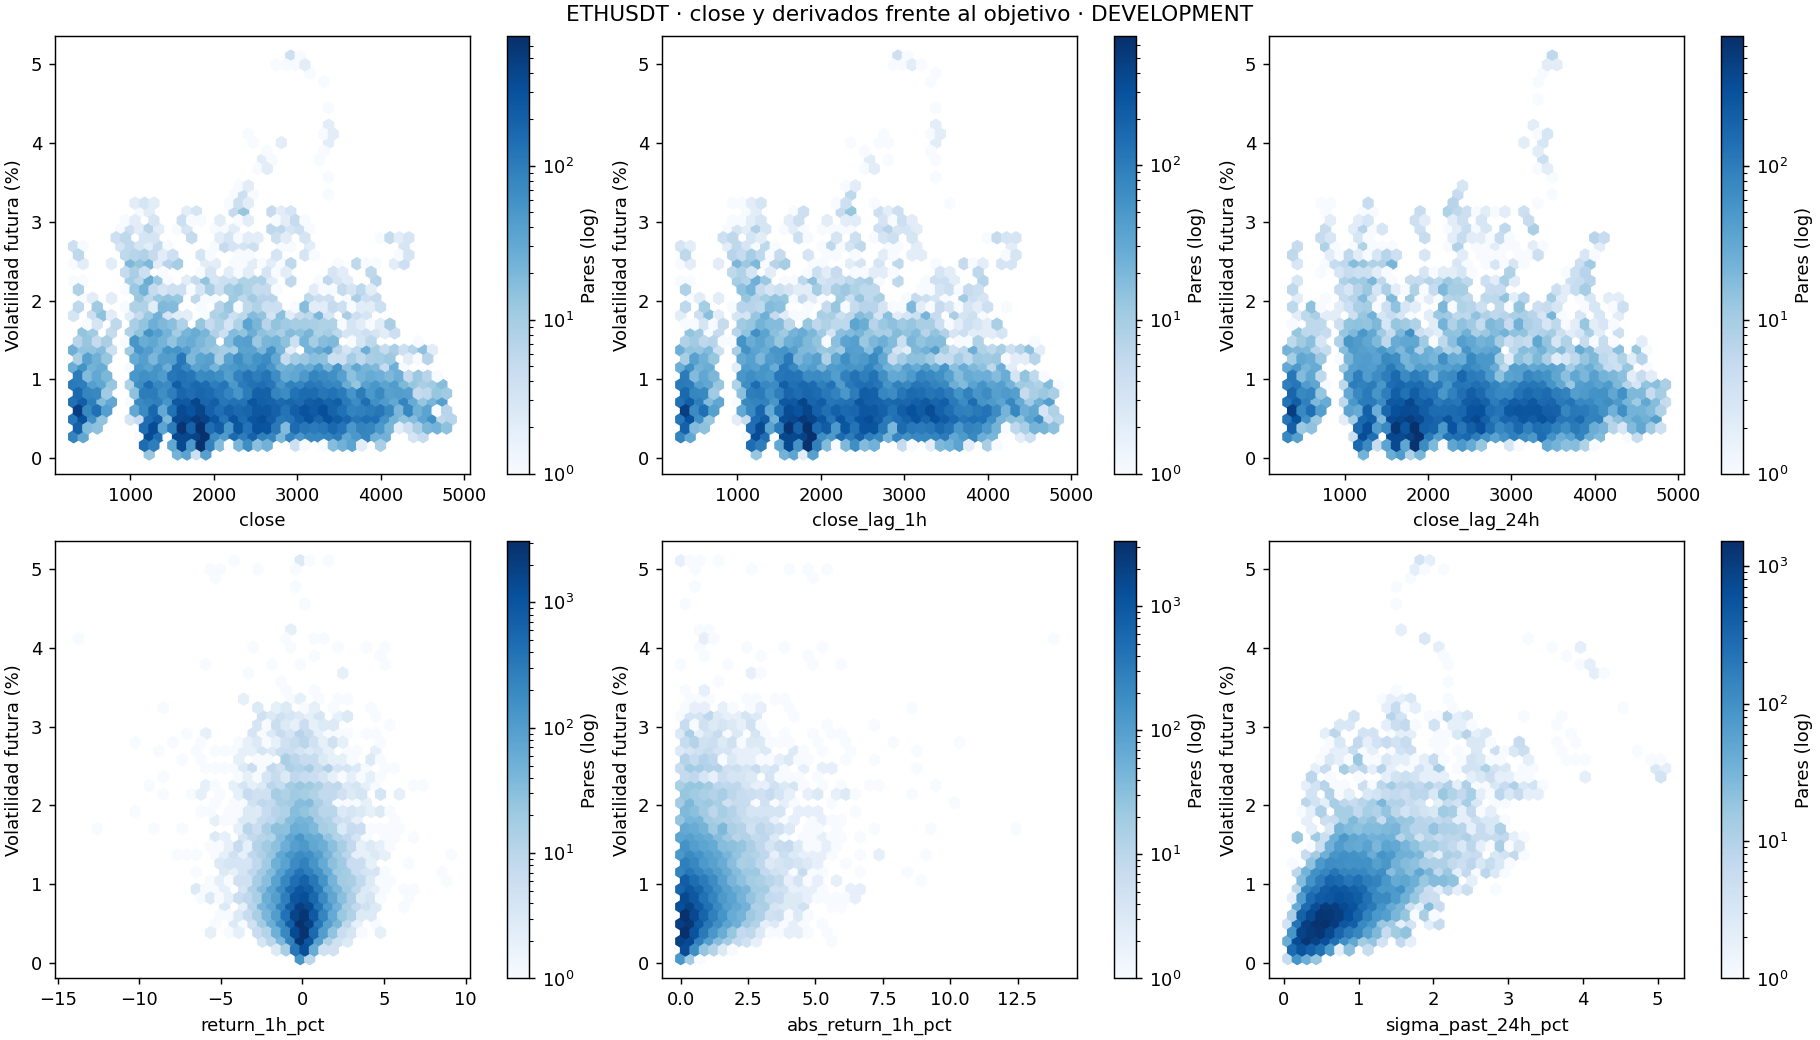

bivariate_groups.png


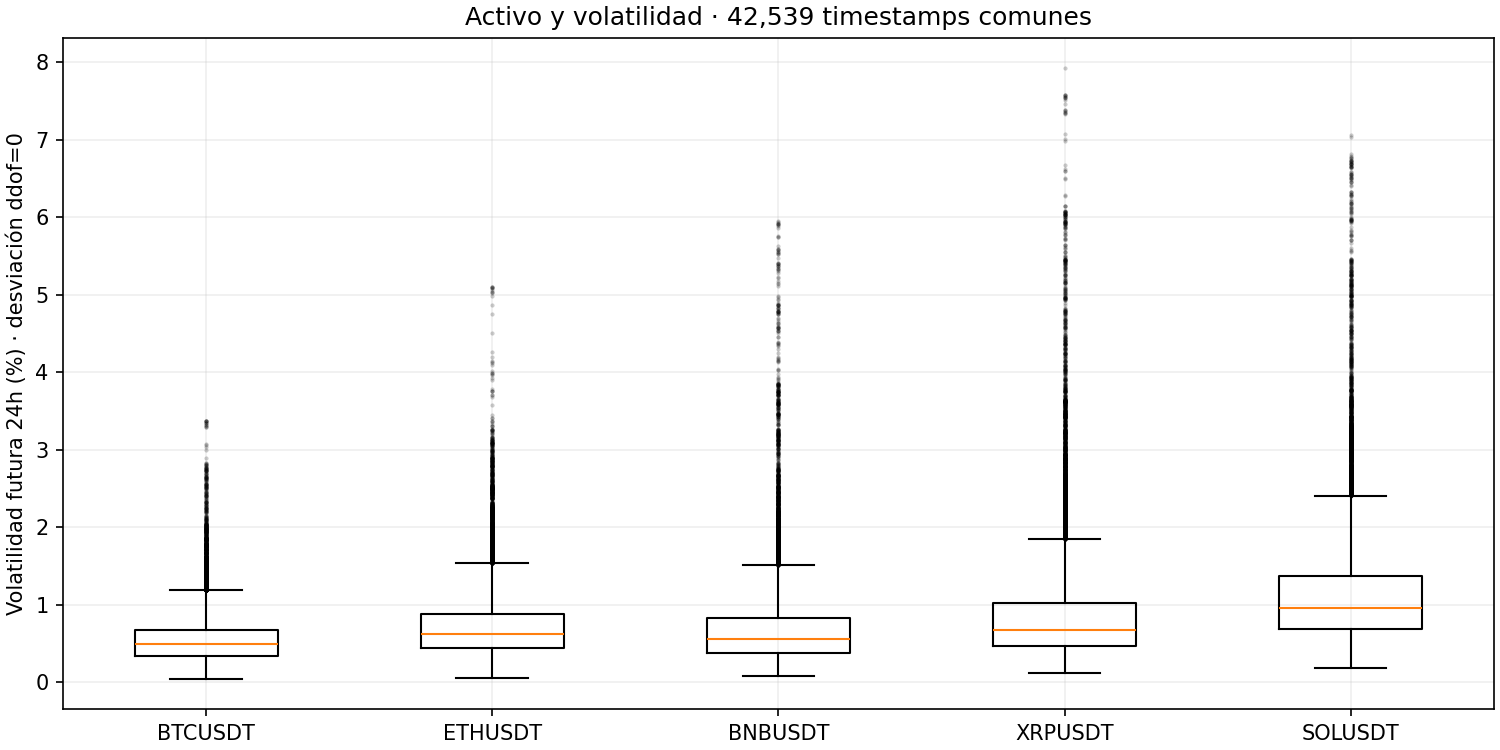

bivariate_heatmap_pearson.png


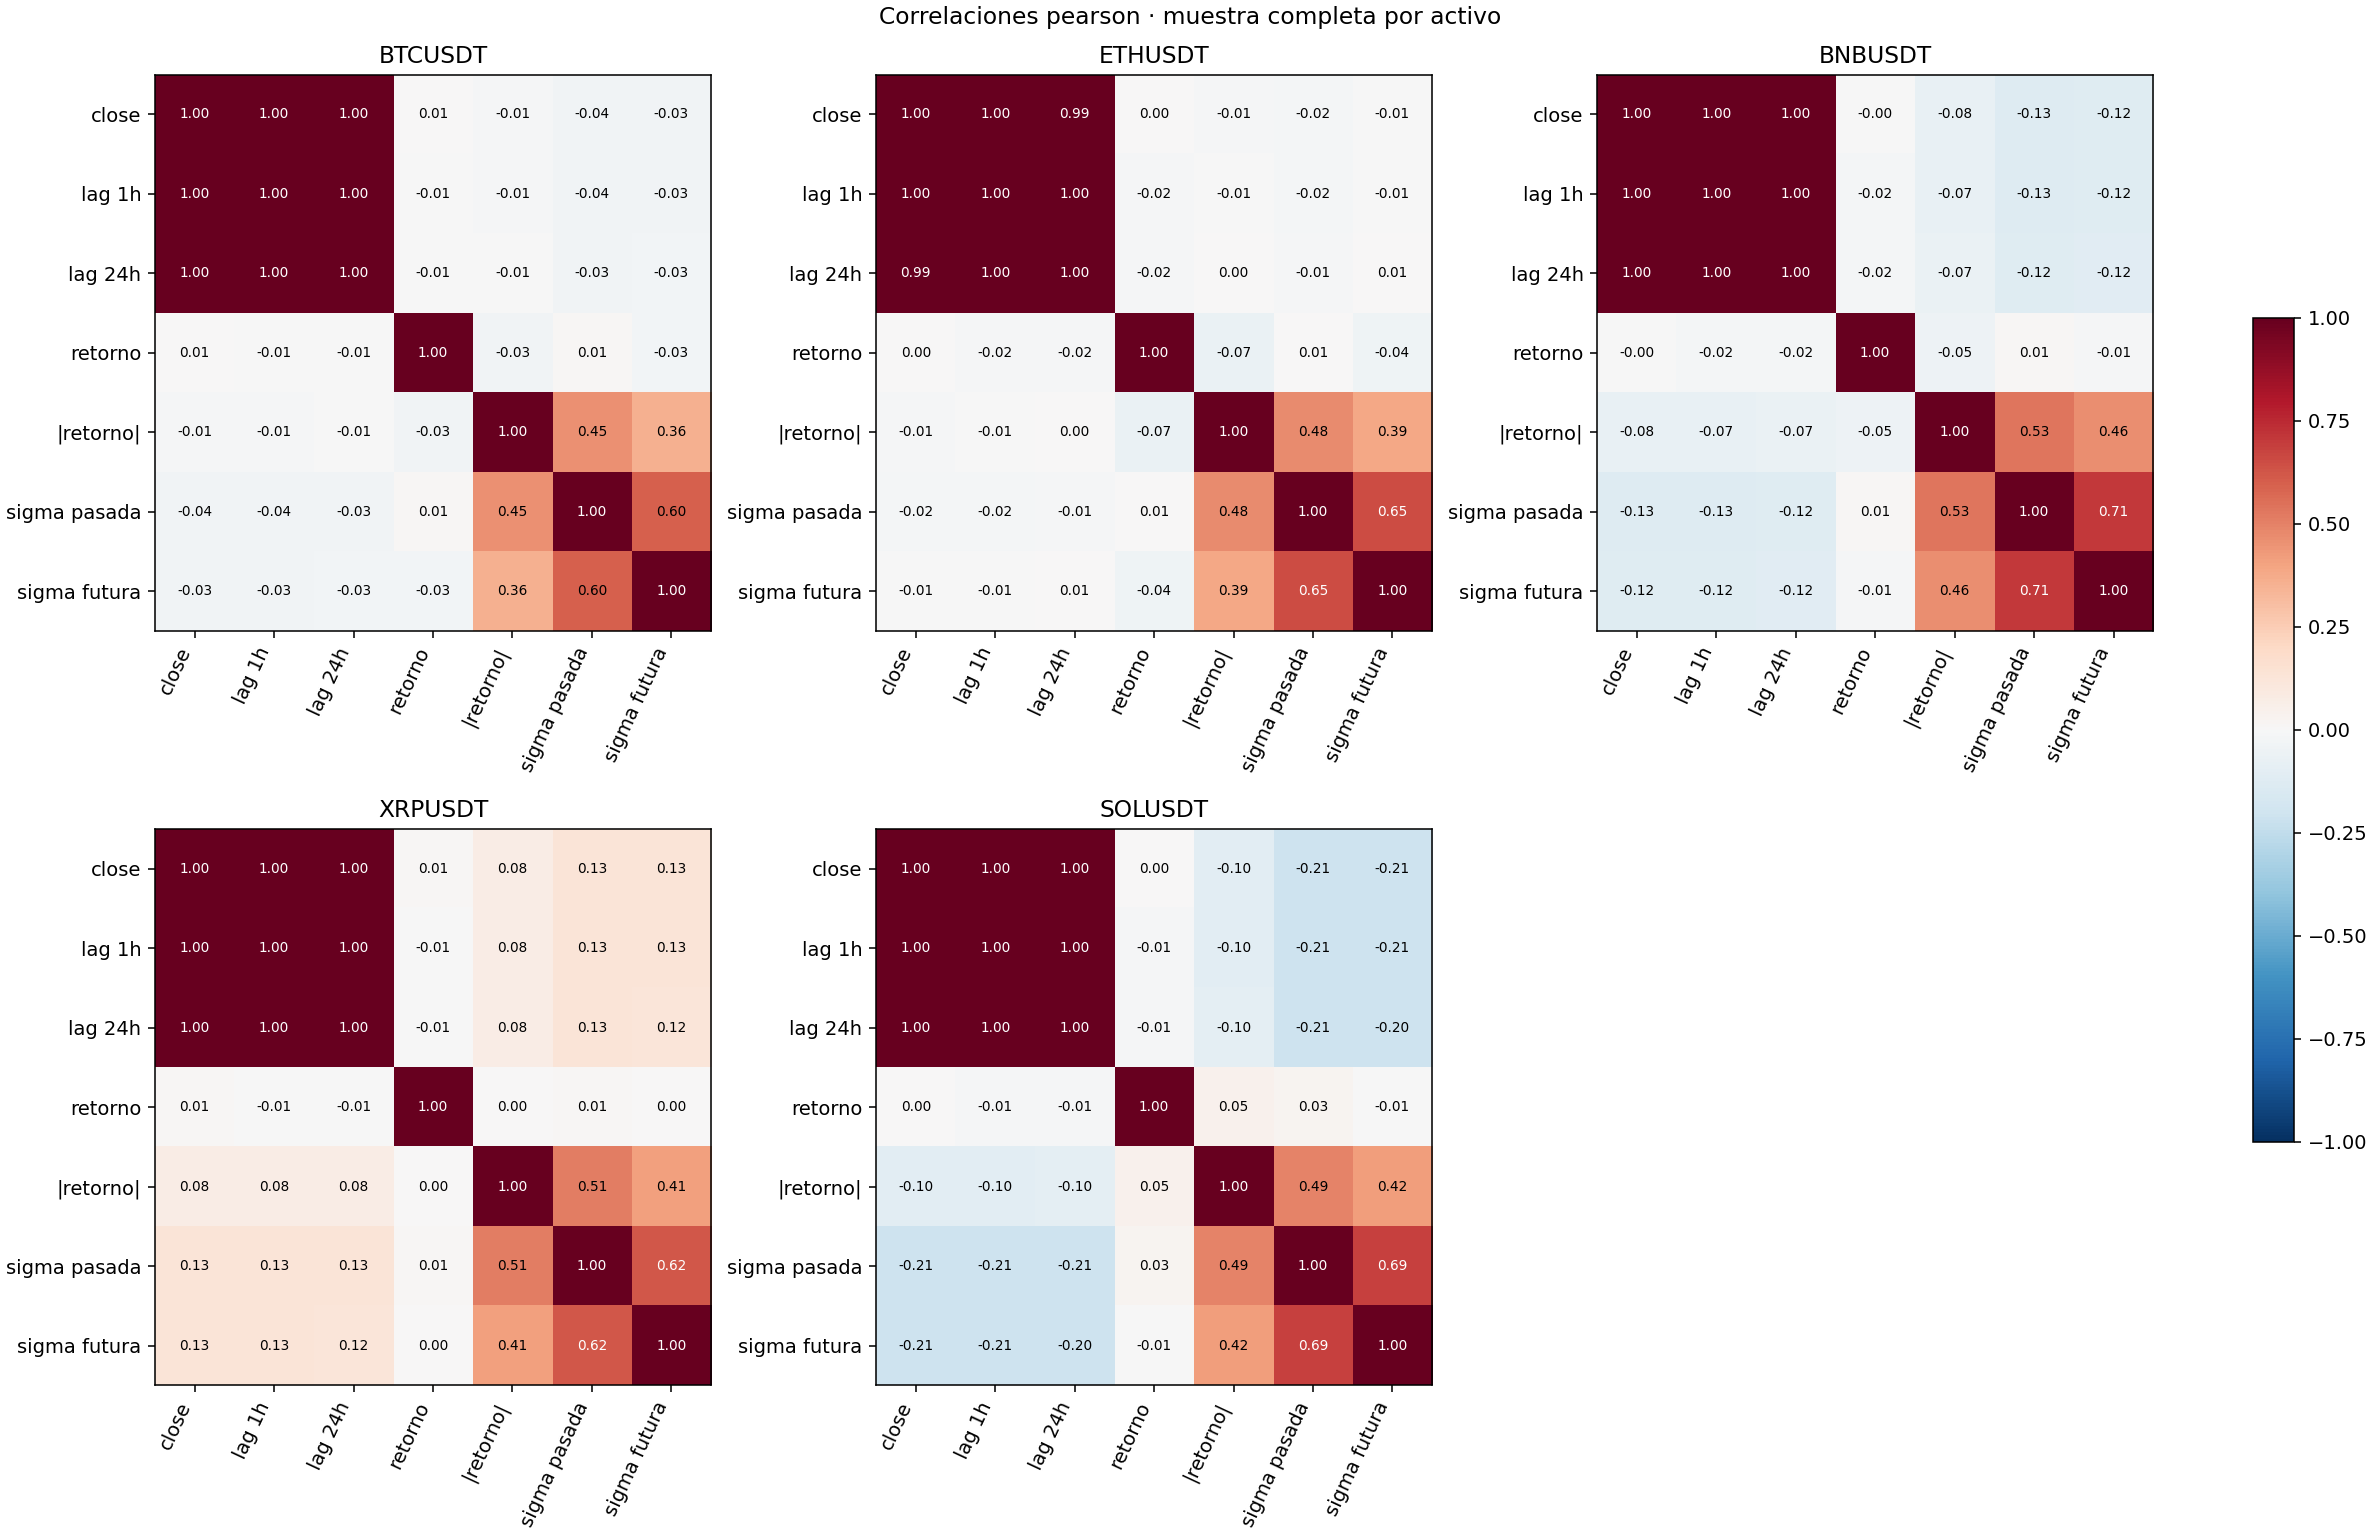

bivariate_heatmap_spearman.png


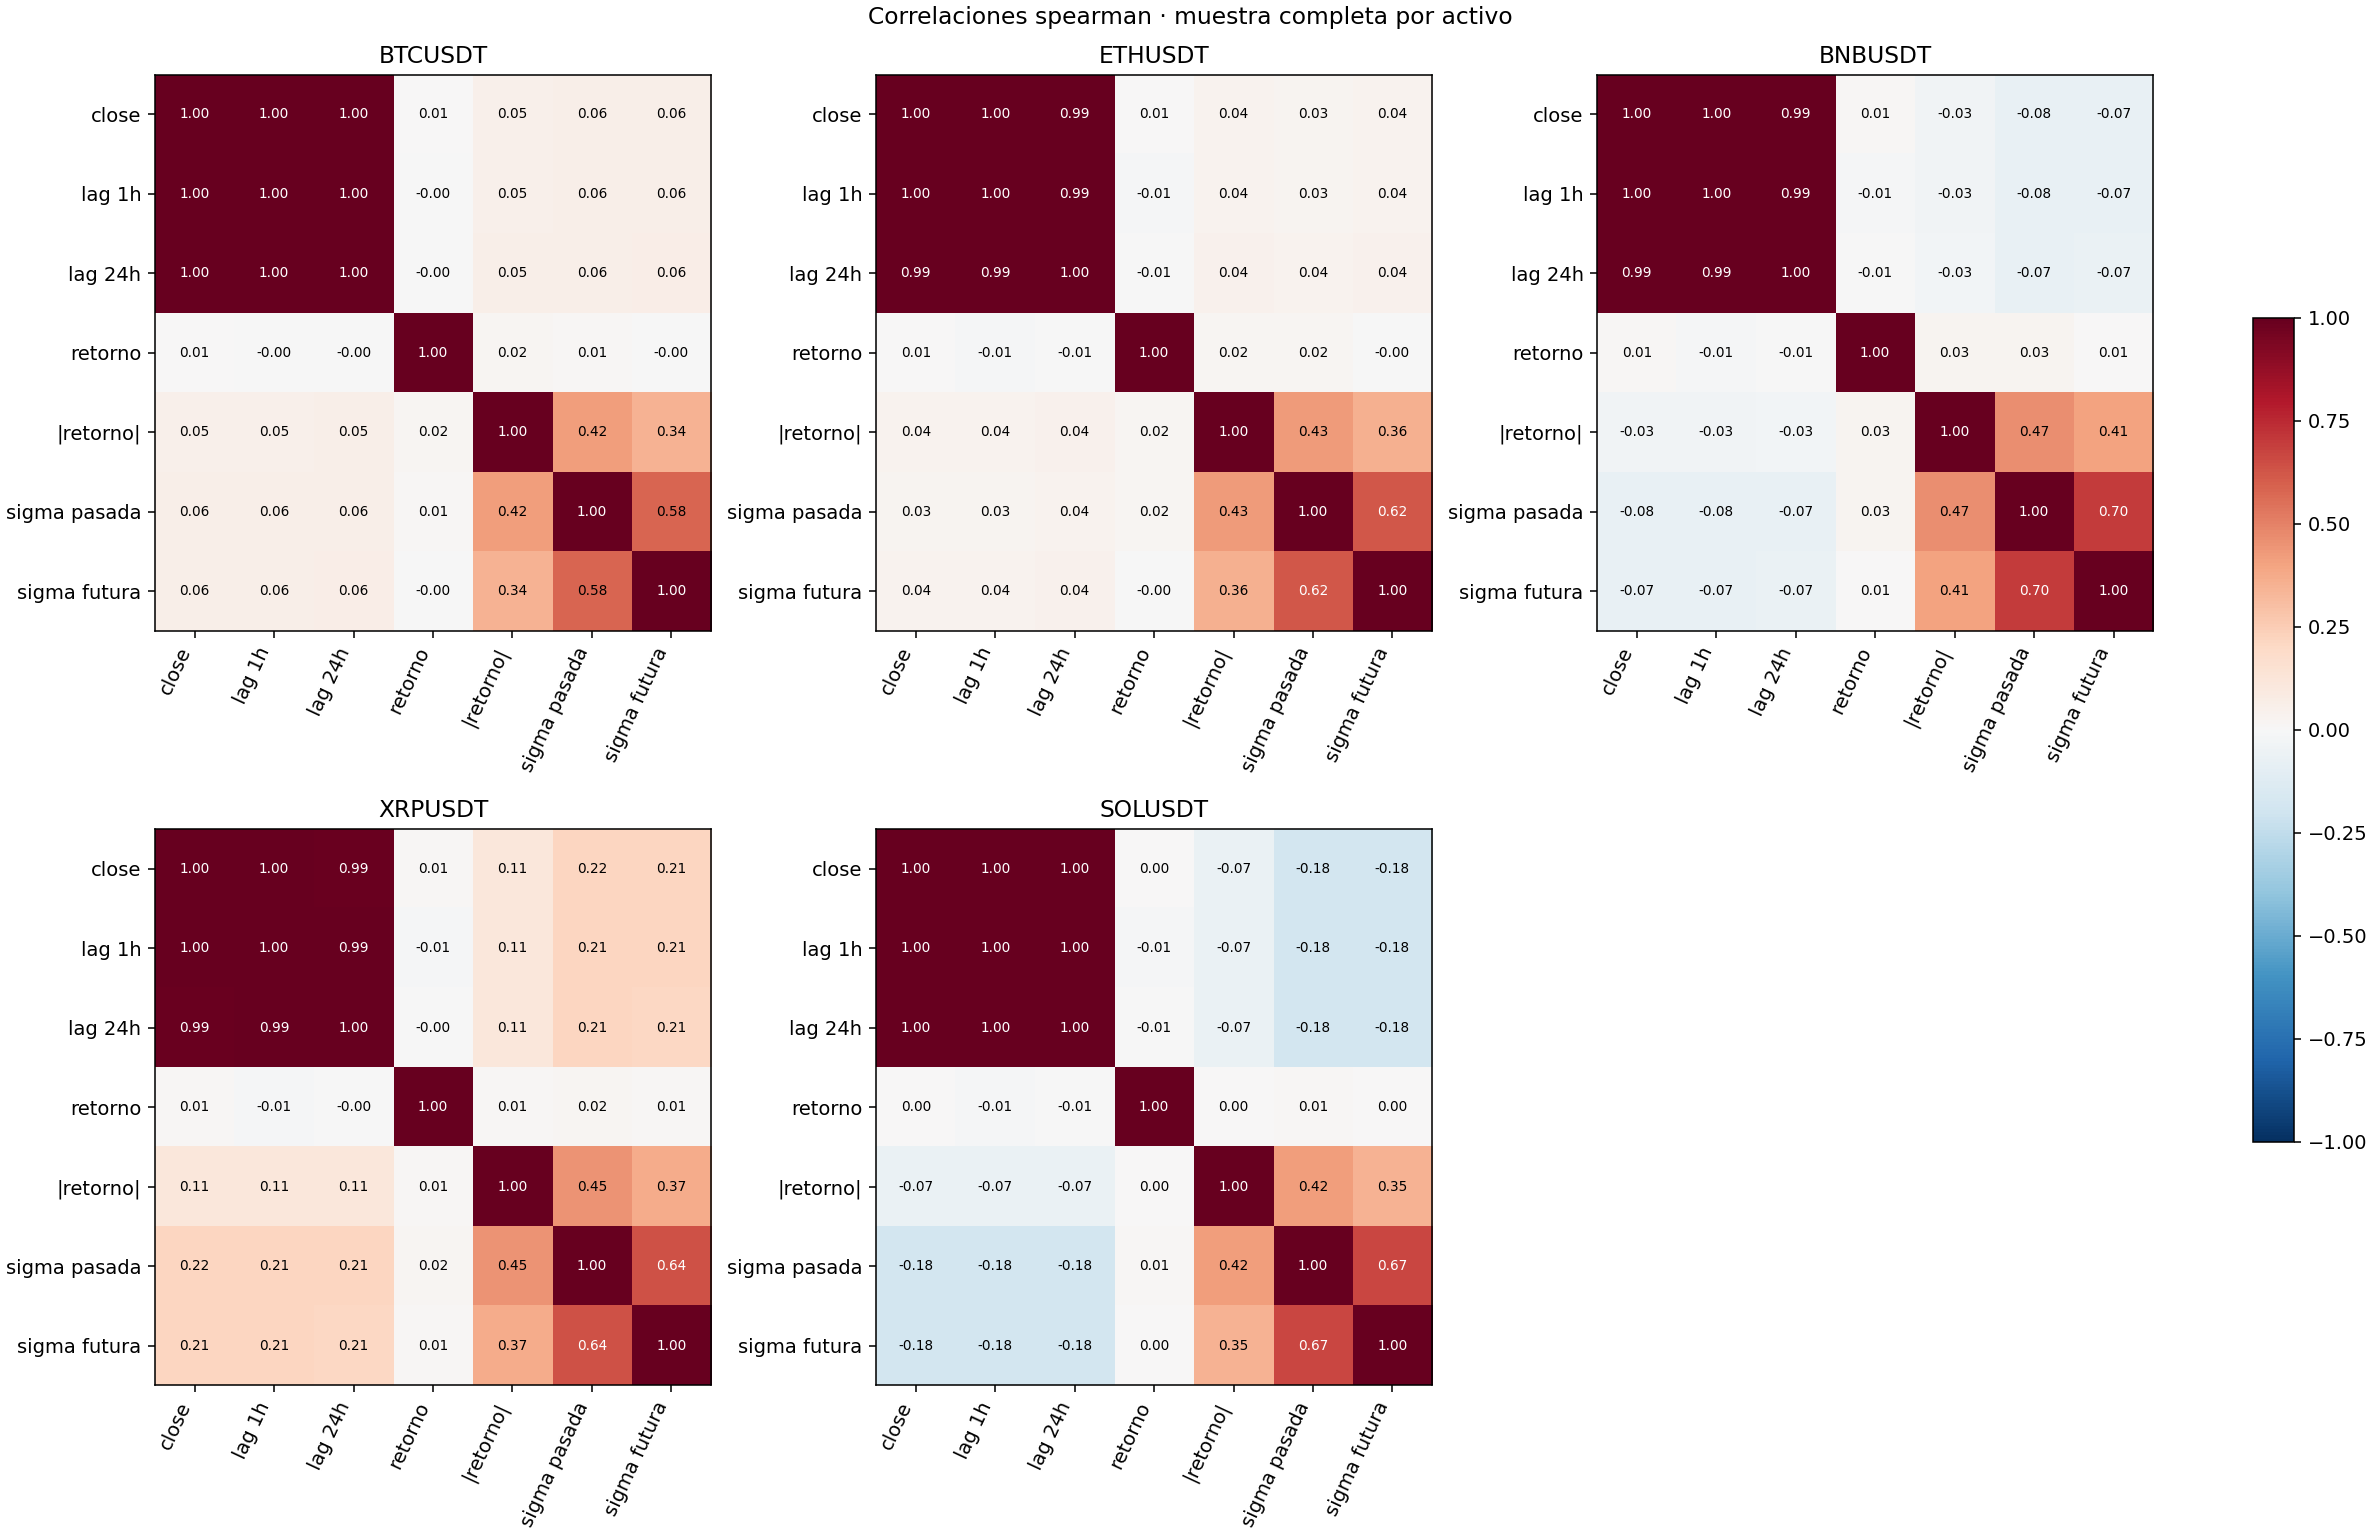

bivariate_SOLUSDT.png


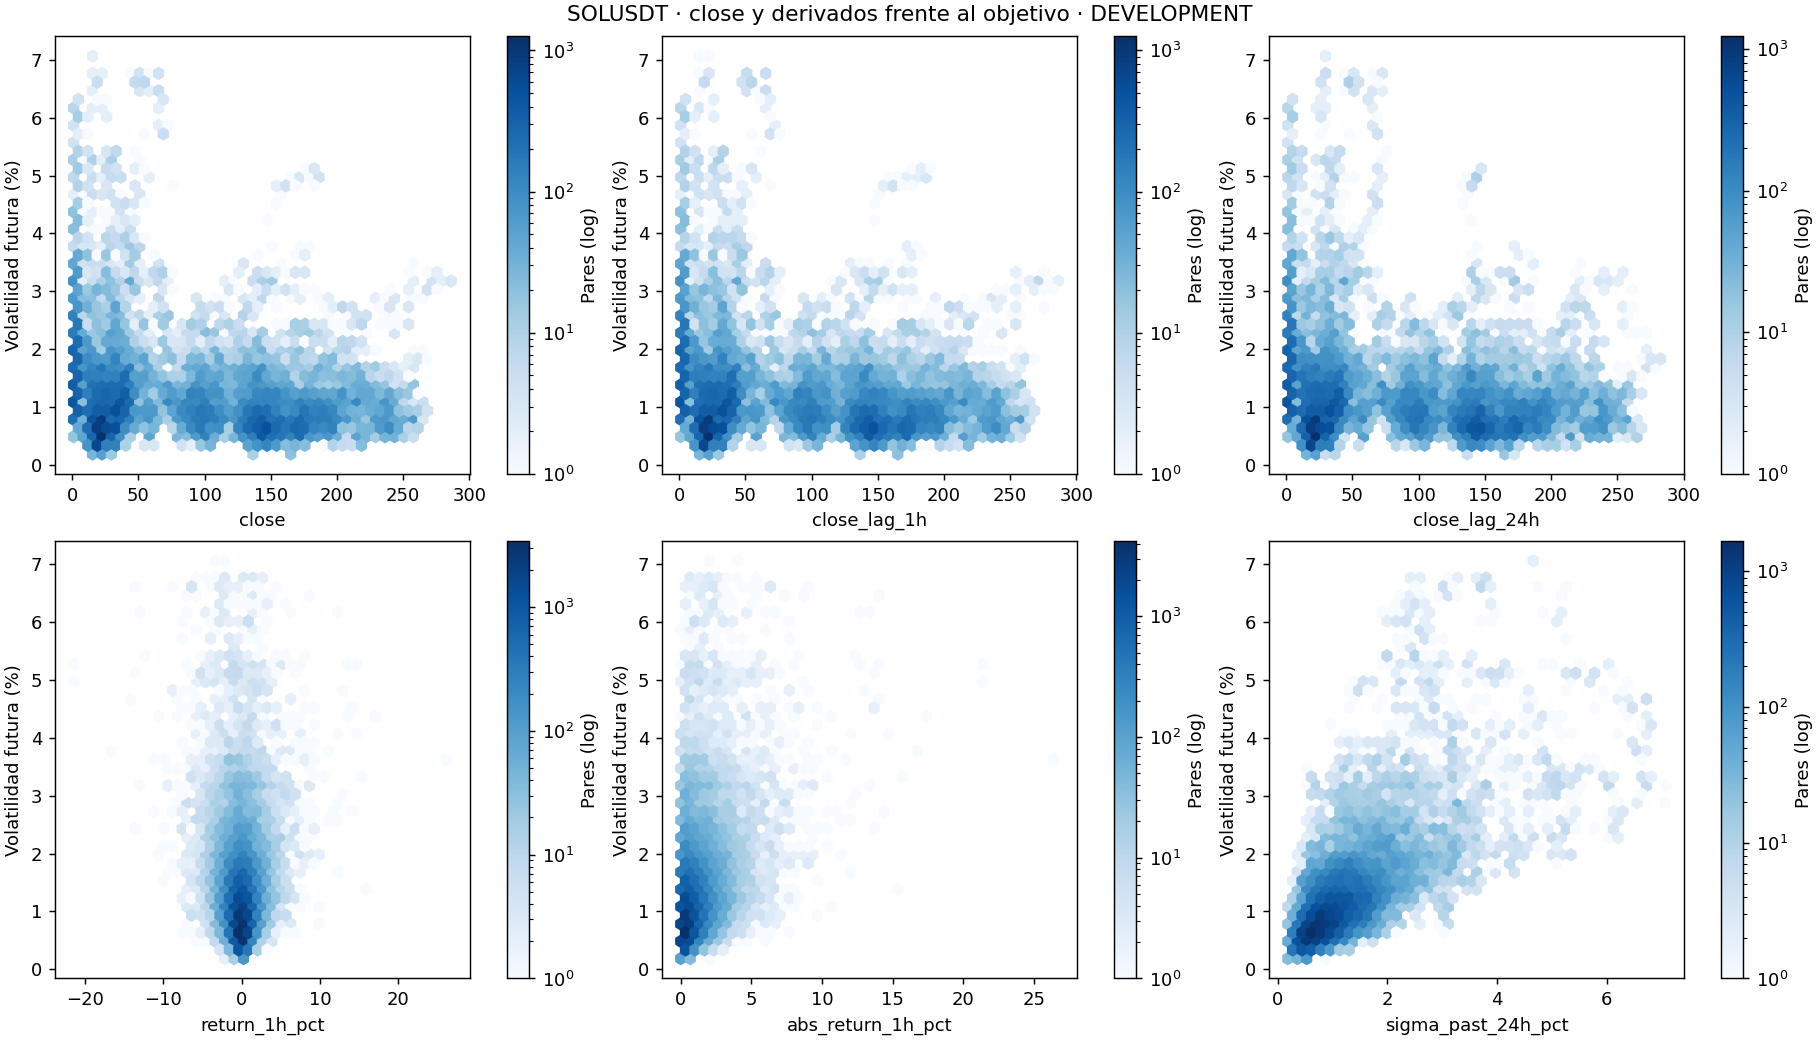

bivariate_XRPUSDT.png


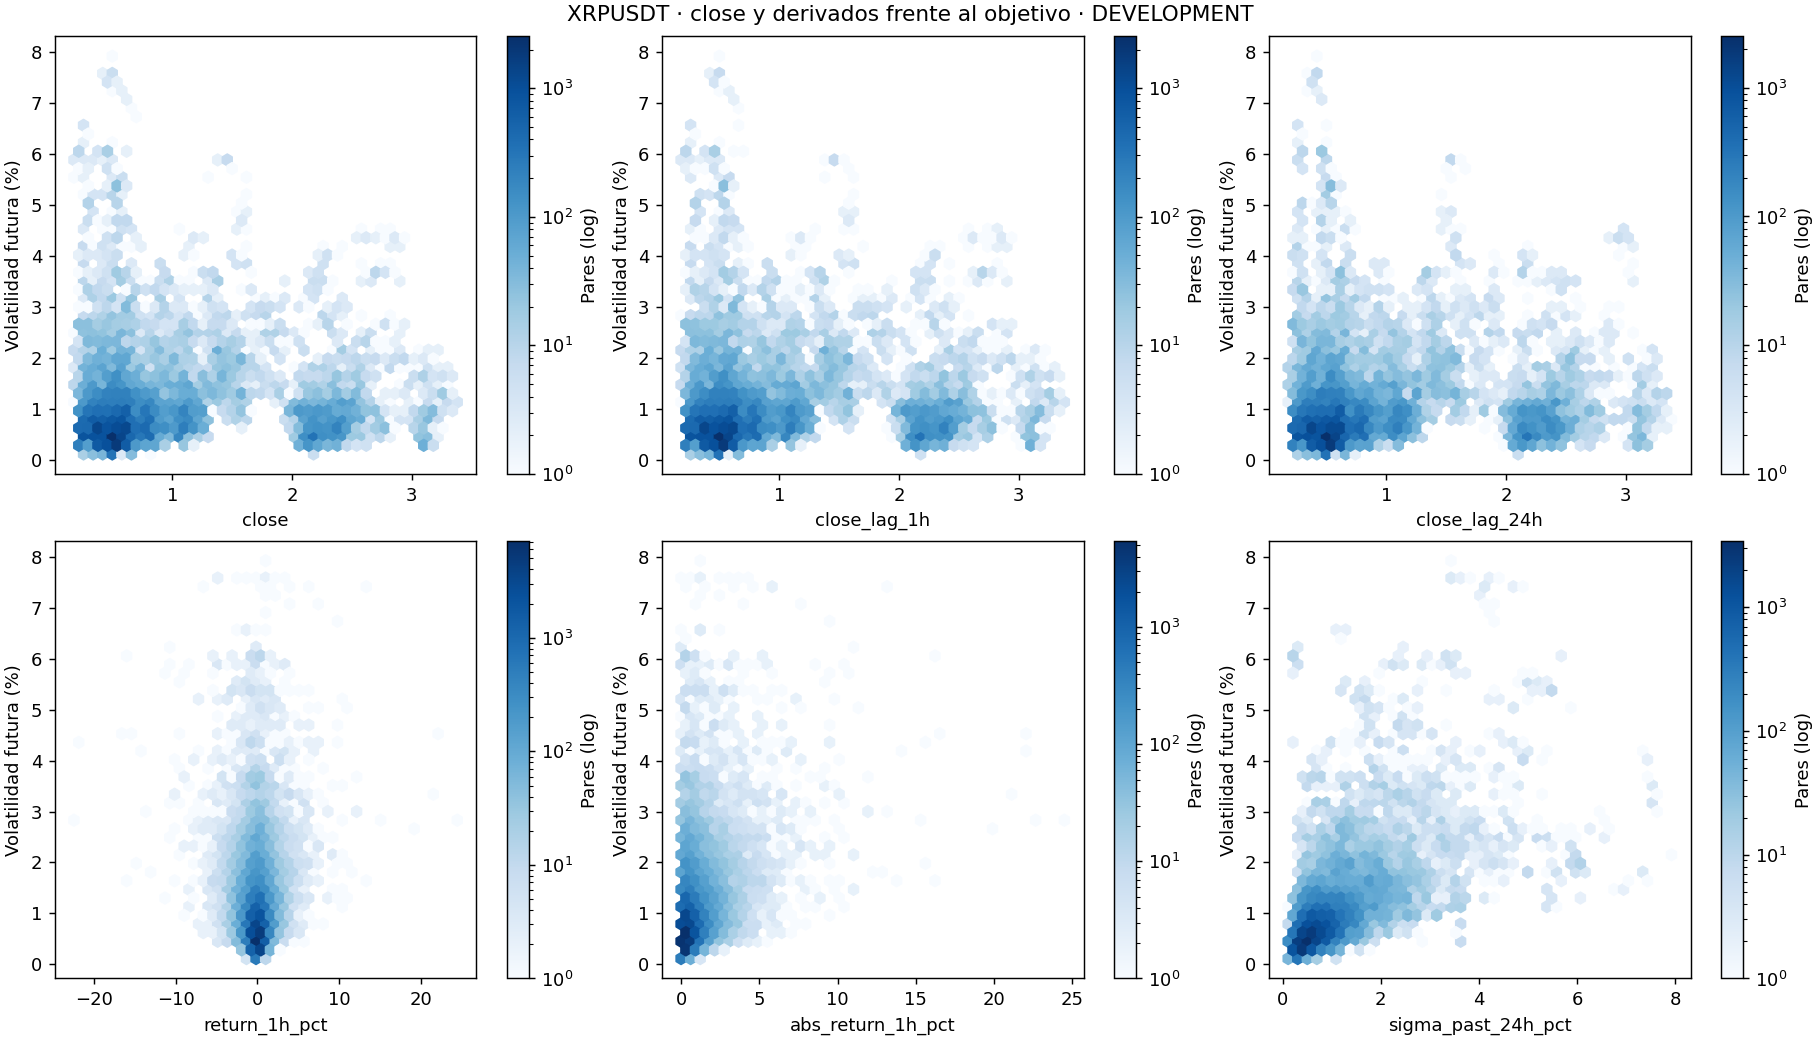

bivariate_associations.csv


,symbol,predictor,n,pearson,spearman,mi_nats
0,BTCUSDT,close,42251,-0.033923,0.060176,0.634727
1,BTCUSDT,close_lag_1h,42251,-0.033553,0.060285,0.595453
2,BTCUSDT,close_lag_24h,42251,-0.027470,0.062980,0.549503
3,BTCUSDT,return_1h_pct,42251,-0.028821,-0.001364,0.084692
4,BTCUSDT,abs_return_1h_pct,42251,0.358978,0.344128,0.076684
5,BTCUSDT,sigma_past_24h_pct,42251,0.596390,0.581812,0.434710
6,ETHUSDT,close,42251,-0.007358,0.035650,0.497366
7,ETHUSDT,close_lag_1h,42251,-0.006425,0.036008,0.460407
8,ETHUSDT,close_lag_24h,42251,0.006969,0.042591,0.436158
9,ETHUSDT,return_1h_pct,42251,-0.041853,-0.003952,0.087436


bivariate_correlations.csv


,symbol,method,row,column,value
0,BTCUSDT,pearson,close,close,1.000000
1,BTCUSDT,pearson,close,close_lag_1h,0.999922
2,BTCUSDT,pearson,close,close_lag_24h,0.998242
3,BTCUSDT,pearson,close,return_1h_pct,0.005028
4,BTCUSDT,pearson,close,abs_return_1h_pct,-0.012492
5,BTCUSDT,pearson,close,sigma_past_24h_pct,-0.037087
6,BTCUSDT,pearson,close,sigma_future_24h_pct,-0.033923
7,BTCUSDT,pearson,close_lag_1h,close,0.999922
8,BTCUSDT,pearson,close_lag_1h,close_lag_1h,1.000000
9,BTCUSDT,pearson,close_lag_1h,close_lag_24h,0.998309


bivariate_coverage.csv


...

,block_hours,asset_a,asset_b,n,difference_pp,paired_effect,ci_low,ci_high,p_raw,p_holm
0,24,BTCUSDT,ETHUSDT,42539,-0.162174,-0.755668,-0.171303,-0.153149,0.0005,0.0050
1,24,BTCUSDT,BNBUSDT,42539,-0.136773,-0.368937,-0.153773,-0.121082,0.0005,0.0050
2,24,BTCUSDT,XRPUSDT,42539,-0.324892,-0.568826,-0.348590,-0.300452,0.0005,0.0050
3,24,BTCUSDT,SOLUSDT,42539,-0.590687,-1.067121,-0.614614,-0.567086,0.0005,0.0050
4,24,ETHUSDT,BNBUSDT,42539,0.025402,0.071511,0.009752,0.039857,0.0025,0.0050
5,24,ETHUSDT,XRPUSDT,42539,-0.162718,-0.291544,-0.186596,-0.138532,0.0005,0.0050
6,24,ETHUSDT,SOLUSDT,42539,-0.428513,-0.864089,-0.450504,-0.407646,0.0005,0.0050
7,24,BNBUSDT,XRPUSDT,42539,-0.188119,-0.330424,-0.212537,-0.162845,0.0005,0.0050
8,24,BNBUSDT,SOLUSDT,42539,-0.453915,-0.903098,-0.475662,-0.431412,0.0005,0.0050
9,24,XRPUSDT,SOLUSDT,42539,-0.265795,-0.399424,-0.295705,-0.238838,0.0005,0.0050


bivariate_group_summary.csv


,Unnamed: 0,count,mean,std,min,25%,50%,75%,max
0,BTCUSDT,42539.0,0.550719,0.331800,0.044503,0.333471,0.485389,0.673761,3.376542
1,ETHUSDT,42539.0,0.712893,0.434405,0.054207,0.435491,0.619569,0.876874,5.105328
2,BNBUSDT,42539.0,0.687491,0.516196,0.078695,0.373111,0.558936,0.829763,5.956585
3,XRPUSDT,42539.0,0.875611,0.701100,0.114430,0.462846,0.676416,1.017698,7.923185
4,SOLUSDT,42539.0,1.141406,0.723015,0.185347,0.681406,0.960687,1.371676,7.064492


bivariate_vif.csv


,symbol,predictor,n,vif
0,BTCUSDT,close,42251,33075.032570
1,BTCUSDT,close_lag_1h,42251,33244.548421
2,BTCUSDT,close_lag_24h,42251,298.395074
3,BTCUSDT,return_1h_pct,42251,5.162860
4,BTCUSDT,abs_return_1h_pct,42251,1.265340
5,BTCUSDT,sigma_past_24h_pct,42251,1.262525
6,ETHUSDT,close,42251,13899.320182
7,ETHUSDT,close_lag_1h,42251,13987.804328
8,ETHUSDT,close_lag_24h,42251,102.973955
9,ETHUSDT,return_1h_pct,42251,6.126232


In [2]:
from IPython.display import display, Image
for path in sorted((ROOT / 'book/_static/figures').glob('bivariate_*.png')):
    print(path.name)
    display(Image(filename=str(path)))
for path in sorted((ROOT / 'outputs/tables').glob('bivariate_*.csv')):
    if 'aligned' not in path.name:
        print(path.name)
        display(pd.read_csv(path).head(40))